In [111]:
!pip install cvxpy[OSQP,ECOS] --upgrade
!pip install gurobipy>=10  # install gurobipy, if not already installed

import numpy as np
from scipy.stats import truncnorm
from sklearn.cluster import KMeans
import gurobipy as gp
import matplotlib.pyplot as plt
import pandas as pd
import cvxpy as cp
import time

# Create an environment with your WLS license
params = {
"WLSACCESSID": 'bd6082d8-df30-497b-86f3-f189f173114f',
"WLSSECRET": '33a99b27-d33d-4640-ab8e-6b4db5d020bd',
"LICENSEID": 2446748,
}
env = gp.Env(params=params)

print("- cvxpy version:", cp.__version__, "-")
print("- cvxpy installed solvers:", cp.installed_solvers())

from google.colab import drive, files

drive.mount('/content/drive')

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2446748
Academic license 2446748 - for non-commercial use only - registered to tn___@columbia.edu
- cvxpy version: 1.4.2 -
- cvxpy installed solvers: ['CLARABEL', 'CVXOPT', 'ECOS', 'ECOS_BB', 'GLPK', 'GLPK_MI', 'GUROBI', 'OSQP', 'SCIPY', 'SCS']
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [98]:
def eps_approx_eq(N, M, D, B, p, x, E2Tol=1e-5, E3Tol=1e-5, report_all=False, ignore_print=False):

    def equal_budget_eps(B, p, x):
        B_ = np.sum(p * x, axis=1)
        eps1 = max(1 - min(B_ / B), 1 - 1 / max(B_ / B))

        return eps1

    def optimal_bundle_eps(N, D, p, x):
        eps2 = 0
        for i in range(N):
            beta = max(p / D[i])
            min_disuti = sum(p * x[i]) / beta
            eps_i = 1 - min_disuti / sum(D[i] * x[i])
            if eps_i > eps2:
                eps2 = eps_i

        return eps2

    def market_clearance_eps(M, x):
        eps3 = max(np.abs(np.sum(x, axis=0) - np.ones(M)))

        return eps3

    eps1 = equal_budget_eps(B, p, x)
    eps2 = optimal_bundle_eps(N, D, p, x)
    eps3 = market_clearance_eps(M, x)

    if report_all:
        if not ignore_print:
            print()
            print("===============================================================")
            print("(E1) Equal Budget \t\t (E2) Optimal Bundle \t\t (E3) Market Clearance")
            print("---------------------------------------------------------------")
            print(f"{eps1} \t\t {eps2} \t\t {eps3}")
            print("---------------------------------------------------------------")

    if eps2 > E2Tol:
        return f"(E2 - optimal_bundle) is not exactly satisfied (eps2 = {eps2})."

    if eps3 > E3Tol:
        return f"(E3 - market_clearance) is not exactly satisfied (eps3 = {eps3})."

    return eps1

APPROXIMATE_THR = 0.02
EXACT_TOL = 1e-5

In [99]:
def polytope_dual(N, M, D, B):
    A = list()
    # use Gurobi, not include the nonnegative constraints
    for i in range(N):
        D_i_T = np.zeros(shape=(M, N))
        D_i_T[:, i] = - D[i]
        A_i = np.concatenate([np.identity(M), D_i_T], axis=1)
        A.append(A_i)
    A = np.concatenate(A, axis=0)
    b = np.zeros(shape=(M * N))
    C = np.concatenate([np.ones(M), np.zeros(N)]).reshape(1, -1)
    d = np.array(sum(B)).reshape(1, )

    return A, b, C, d

def feasible_point(M, N, D, B, random=False, random_seed=2024):  ###
    if random:
        np.random.seed(random_seed)
        p_0 = np.random.uniform(size=M)
        p_0 = p_0 / sum(p_0) * sum(B)
        beta_0 = np.amax(p_0 / D, axis=1) + np.random.uniform(size=N)
    else:
        p_0 = (sum(B) / M) * np.ones(shape=M)
        beta_0 = np.amax(p_0 / D, axis=1)

    return p_0, beta_0

def LMO(c, A, b, C=None, d=None, return_dual=False):
    m = gp.Model(env=env)
    N = len(c)

    M = A.shape[1] - len(c)
    p = m.addMVar(M)
    beta = m.addMVar(len(c))

    m.setObjective(c @ beta)
    m.addConstr(A[:, :M] @ p + A[:, M:] @ beta <= b)
    if C is not None and d is not None:
        m.addConstr(C[:, :M] @ p + C[:, M:] @ beta == d)
    # m.PStart = x0

    m.Params.LogToConsole = 0
    # m.Params.Method = 1
    m.optimize()

    if return_dual:
        return p.X, beta.X, np.array(m.Pi)
    else:
        return p.X, beta.X

def GFW(N, M, D, B, return_eq=False):  # Greedy Frank Wolfe

    # create the dual polyhedron
    A, b, C, d = polytope_dual(N, M, D, B)

    # initialize
    MAX_NUM_ITER = 50
    num_LMO_a1, num_LMO_e = MAX_NUM_ITER, MAX_NUM_ITER
    solved_a1, solved_e = False, False
    running_time_a1, running_time_e = None, None

    # counters
    num_LMO = 0
    running_time = 0

    # analysis
    solve_LP_time = 0
    solve_LP_num = 0

    p, beta = feasible_point(M, N, D, B)
    beta_ = beta  # 'beta_' keeps the last beta values

    for k in range(MAX_NUM_ITER):

        # main
        LP_start = GFW_start = time.time()

        p, beta, gamma = LMO(B / beta, A, b, C, d, return_dual=True)

        solve_LP_time += time.time() - LP_start
        solve_LP_num += 1
        num_LMO += 1

        x = -gamma[: N * M].reshape(N, M)
        x = sum(B) / sum(B * beta / beta_) * x
        beta_ = beta

        running_time += time.time() - GFW_start

        # evaluation
        eps = eps_approx_eq(N, M, D, B, p, x, ignore_print=True)

        if type(eps) is str:
            print(eps)
            break  # terminate the algorithm

        if type(eps) is not str:
            if eps <= APPROXIMATE_THR and num_LMO_a1 == MAX_NUM_ITER:  # the second condition ensures that 'num_LMO_1' has not been updated
                solved_a1 = True
                num_LMO_a1 = num_LMO
                running_time_a1 = running_time

            if eps <= EXACT_TOL:
                solved_e = True
                num_LMO_e = num_LMO
                running_time_e = running_time
                break

    # print("Average LP solving time:", solve_LP_time / solve_LP_num)
    if return_eq:
        if solved_e:
            print("p:\n", np.round(p, 3))
            print("x:\n", np.round(x, 3))
            print("u:\n", np.round(B / beta, 3))
    return num_LMO_a1, num_LMO_e, solved_a1, solved_e, running_time_a1, running_time_e

In [101]:
def poly_ext_primal(N, M, D, B):
    A = list()
    A.append(np.zeros(shape=(N, N + M * N)))
    for i in range(N):
        A[0][i, i] = -1
        A[0][i, N + i * M: N + i * M + M] = D[i]
    # show add x is nonnegative constraint when solving QP using some solver
    A = np.concatenate(A, axis=0)
    b = np.zeros(N)
    C = np.zeros(shape=(M, N + M * N))
    for j in range(M):
        C[j, N + j: N + M * N: M] = 1
    d = np.ones(M)

    return A, b, C, d

def QMO(ux0, N, A, b, C=None, d=None, solver='OSQP'):
    if solver == 'OSQP':
        ux = cp.Variable(len(ux0), nonneg=True)
        obj = cp.Minimize(sum((ux[:N] - ux0[:N]) ** 2))
        constraints = [A @ ux <= b, ]
        if C is not None and d is not None:
            constraints.append(C @ ux == d)
        prob = cp.Problem(obj, constraints)
        try:
            prob.solve(solver='OSQP', max_iter=100000, verbose=False)
        except:
            return ux0, np.float64(10000000)  # should change this
        # print(prob.status)

        return ux.value, prob.value

    elif solver == 'GUROBI':
        m = gp.Model(env=env)

        m.Params.LogToConsole = 0
        m.Params.FeasibilityTol = 1e-9
        m.Params.OptimalityTol = 1e-9
        m.Params.BarConvTol = 1e-15
        m.Params.BarCorrectors = 10000

        u = m.addMVar(N)
        x = m.addMVar(A.shape[1] - N)
        u0 = ux0[:N]
        m.setObjective((u - u0) @ (u - u0))
        m.addConstr(A[:, :N] @ u + A[:, N:] @ x <= b)
        if C is not None and d is not None:
            m.addConstr(C[:, :N] @ u + C[:, N:] @ x == d)

        m.optimize()

        obj = m.getObjective()

        return np.concatenate([u.X, x.X]), obj.getValue()

def print_quality_QMO(x_value, obj_value, N, A, b, C=None, d=None, solver_name="Unnamed"):
    feasibility_tol = np.maximum(A @ x_value - b, 0)
    if C is not None and d is not None:
        feasibility_tol_eq = np.abs(C @ x_value - d)
    print("---")
    print("Solver Name:", solver_name)
    print("Max Feasibility Tolerance:", max(max(feasibility_tol), max(feasibility_tol_eq)))
    print("Objective Value (Min Dist)", obj_value)

def find_X(N, M, u, A, b, C=None, d=None):
    m = gp.Model(env=env)

    x = m.addMVar(N * M)
    eps = m.addVar()

    m.setObjective(eps)
    m.addConstr(A[:, N:] @ x - eps <= u)
    if C is not None and d is not None:
        m.addConstr(C[:, N:] @ x == d)

    m.Params.LogToConsole = 0
    m.Params.FeasibilityTol = 1e-6
    m.Params.OptimalityTol = 1e-6
    m.optimize()
    # m.printQuality()

    if eps.X <= 1e-12:  # high accuracy required on finding a feasible (or over-allocated) allocation
        return x.X.reshape(N, M)
    else:
        return "There is no feasible allocation corresponding to given disutility.", eps.X

def u_is_feasible(N, M, u, A, b, C=None, d=None):
    X = find_X(N, M, u, A, b, C, d)
    if type(X) is np.ndarray:
        return True, X
    else:
        return False, None

def EPM(N, M, D, B, QMO_solver='best', print_quality=False, print_progress=False, ignore_print=False, return_eq=False):

    # construct extended (u, x) polyhedral
    A, b, C, d = poly_ext_primal(N, M, D, B)

    # pick an initial (infeasible) point (near 0)
    u = u0 = np.amin(D, axis=1) / (N + 1) ** 2  # or / (N + 1)

    # initialize
    MAX_NUM_ITER = 50
    MAX_FEASIBILITY_TOL = 1e-6
    num_QMO_a1, num_QMO_e = MAX_NUM_ITER, MAX_NUM_ITER
    solved_a1, solved_e = False, False
    running_time_a1, running_time_e = None, None

    # counters
    num_QMO = 0
    running_time = 0

    # analysis
    solve_QP_time = 0
    solve_QP_num = 0

    for k in range(MAX_NUM_ITER):

        # main
        QP_start = EPM_start = time.time()

        # choose the solver which performs best on this iteration
        if QMO_solver == 'best':
            solver_list = ['OSQP', 'GUROBI', 'MOSEK']
            res_dict = {
                'solver': [],
                'feasibility tolerance (ineq)': [],
                'feasibility tolerance (eq)': [],
                'objective value': [],
                'feasible objective value': []
            }
            u_obj_list = []
            for solver in solver_list:
                u_, min_dist = QMO(np.concatenate([u, np.zeros(M * N)]),
                            N,
                            np.concatenate([A, np.concatenate([-np.identity(N), np.zeros((N, M * N))], axis=1)], axis=0),
                            np.concatenate([b, -u]),
                            C,
                            d,
                            solver=solver
                )

                feasibility_tol_ineq = np.maximum(A @ u_ - b, 0)
                if C is not None and d is not None:
                    feasibility_tol_eq = np.abs(C @ u_ - d)
                res_dict['solver'].append(solver)
                res_dict['feasibility tolerance (ineq)'].append(max(feasibility_tol_ineq))
                res_dict['feasibility tolerance (eq)'].append(max(feasibility_tol_eq))
                res_dict['objective value'].append(min_dist)
                if max(max(feasibility_tol_ineq), max(feasibility_tol_eq)) > MAX_FEASIBILITY_TOL:
                    res_dict['feasible objective value'].append(np.inf)  # only consider feasible solution
                else:
                    res_dict['feasible objective value'].append(min_dist)
                u_obj_list.append((u_, min_dist))
            # print(type(res_dict['objective value'][0]))
            res_dict[f'obj value vs {solver_list[0]}'] = res_dict['objective value'] - res_dict['objective value'][0]

            selected_solver = solver_list[np.argmin(res_dict['feasible objective value'])]
            u_, min_dist = u_obj_list[np.argmin(res_dict['feasible objective value'])]
            if print_quality:
                res_table = pd.DataFrame(res_dict)
                display(res_table)
                print(selected_solver)

        # choose one specific solver
        else:
            ux_, min_dist = QMO(np.concatenate([u, np.zeros(M * N)]),
                            N,
                            np.concatenate([A, np.concatenate([-np.identity(N), np.zeros((N, M * N))], axis=1)], axis=0),
                            np.concatenate([b, -u]),
                            C,
                            d,
                            solver=QMO_solver
            )
            solve_QP_time += time.time() - QP_start
            solve_QP_num += 1
            if print_quality:
                print_quality_QMO(u_, min_dist, N, A, b, C, d, solver_name=QMO_solver)

        u_, x = ux_[:N], ux_[N:].reshape(N, M)
        a = u_ - u
        a = N * a / sum(a * u_)
        u = 1 / a

        running_time += time.time() - EPM_start
        num_QMO += 1

        # evaluation
        c = a.reshape(-1, 1) * D
        p = np.amin(c, axis=0)
        try:
            eps = eps_approx_eq(N, M, D, B, p, x)
        except:
            print("--- Note ---")
            break

        next_u_is_feasible, x = u_is_feasible(N, M, u, A, b, C, d)

        if type(eps) is str and next_u_is_feasible:  # a, p are not precise, choose: report unsolved
            break
        if type(eps) is not str and eps > 1:
            break
        if type(eps) is not str:
            if eps <= APPROXIMATE_THR and num_QMO_a1 == MAX_NUM_ITER:
                solved_a1 = True
                num_QMO_a1 = num_QMO
                running_time_a1 = running_time
        if print_progress:
            print(eps)

        if next_u_is_feasible:
            c = a.reshape(-1, 1) * D
            p = np.amin(c, axis=0)
            if ignore_print:
                eps = eps_approx_eq(N, M, D, B, p, x, ignore_print=True)
            elif print_progress:
                eps = eps_approx_eq(N, M, D, B, p, x, report_all=True)
            else:
                eps = eps_approx_eq(N, M, D, B, p, x)

            if type(eps) is not str and eps <= APPROXIMATE_THR and num_QMO_a1 > num_QMO:
                solved_a1 = True
                num_QMO_a1 = num_QMO
                running_time_a1 = running_time

            if type(eps) is not str and eps <= EXACT_TOL:
                solved_e = True
                num_QMO_e = num_QMO
                running_time_e = running_time

            if print_progress:
                print()
            break

    # print("Average QP solving time:", solve_QP_time / solve_QP_num)
    if return_eq:
        if solved_e:
            print("p:\n", np.round(p, 3))
            print("x:\n", np.round(x, 3))
            print("u:\n", np.round(u, 3))
    return num_QMO_a1, num_QMO_e, solved_a1, solved_e, running_time_a1, running_time_e

In [109]:
def run_GFW_vs_EPM(N, M, random_generating_method='uniform', num_seeds=10, num_iter_max_cap=100, running_time_max_cap=100, return_eq=False):

    def average(lst):  # return the average of a list
        num_nonNone = 0
        sum = 0

        for e in lst:
            if e is not None:
                num_nonNone += 1
                sum += e

        if num_nonNone > 0:
            return sum / num_nonNone
        else:
            return np.inf

    seeds = range(num_seeds)  # set how many instances we want to try for one size
    num_LMO_list = [[], []]
    running_time_GFW_list = [[], []]
    num_ins_GFW_solved = [0, 0]
    data_GFW = {
        'size': f'N*M = {N}*{M}',
        'num-iter-a1': None,
        'num-iter-e': None,
        'solved-a1': None,
        'solved-e': None,
        'running-time-a1': None,
        'running-time-e': None,
    }
    num_QMO_list = [[], []]
    running_time_EPM_list = [[], []]
    num_ins_EPM_solved = [0, 0]
    data_EPM = {
        'size': f'N*M = {N}*{M}',
        'num-iter-a1': None,
        'num-iter-e': None,
        'solved-a1': None,
        'solved-e': None,
        'running-time-a1': None,
        'running-time-e': None,
    }

    print(f"-*-*-*- SIZE: {N}*{M} -*-*-*-")
    print("PROGRESS: ", end ="")

    for s in seeds:
        np.random.seed(s)
        if random_generating_method == 'randint':
            D = np.random.randint(low=1, high=1001, size=(N, M))
        elif random_generating_method == 'uniform':
            D = np.random.uniform(size=(N, M))
        elif random_generating_method == 'lognormal':
            D = np.random.lognormal(size=(N, M))
        elif random_generating_method == 'truncnormal':
            D = truncnorm.rvs(a=1e-3, b=10, size=(N, M), random_state=s)
        elif random_generating_method == 'exponential':
            D = np.random.exponential(size=(N, M))

        # d_buyers = np.abs(np.random.normal(size=N))
        # d_items = np.abs(np.random.normal(size=M))
        # d_buyers = np.abs(np.random.normal(size=N))
        # d_items = np.abs(np.random.normal(size=M))
        # D = np.maximum(d_buyers @ d_items.reshape(-1, 1) + 0.1 * np.random.uniform(size=(N, M)), 1e-3)

        B = np.ones(shape=N)

        '''
        Run the Greedy Frank Wolfe algorithm
        '''

        res_GFW = GFW(N, M, D, B, return_eq=return_eq)
        res_EPM = EPM(N, M, D, B, QMO_solver='GUROBI', ignore_print=True, return_eq=return_eq)

        if s + 1 < num_seeds:
            print("o", end ="")
        else:
            print("o")

        for i in range(2):
            num_ins_GFW_solved[i] += res_GFW[2 + i]
            num_ins_EPM_solved[i] += res_EPM[2 + i]
            if res_GFW[2 + i]:
                num_LMO_list[i].append(res_GFW[i])
                running_time_GFW_list[i].append(res_GFW[4 + i])
            if res_EPM[2 + i]:
                num_QMO_list[i].append(res_EPM[i])
                running_time_EPM_list[i].append(res_EPM[4 + i])

    data_GFW['num-iter-a1'] = min(average(num_LMO_list[0]), num_iter_max_cap)
    data_GFW['num-iter-e'] = min(average(num_LMO_list[1]), num_iter_max_cap)
    data_GFW['solved-a1'] = num_ins_GFW_solved[0]
    data_GFW['solved-e'] = num_ins_GFW_solved[1]
    data_GFW['running-time-a1'] = min(average(running_time_GFW_list[0]), running_time_max_cap)
    data_GFW['running-time-e'] = min(average(running_time_GFW_list[1]), running_time_max_cap)

    data_EPM['num-iter-a1'] = min(average(num_QMO_list[0]), num_iter_max_cap)
    data_EPM['num-iter-e'] = min(average(num_QMO_list[1]), num_iter_max_cap)
    data_EPM['solved-a1'] = num_ins_EPM_solved[0]
    data_EPM['solved-e'] = num_ins_EPM_solved[1]
    data_EPM['running-time-a1'] = min(average(running_time_EPM_list[0]), running_time_max_cap)
    data_EPM['running-time-e'] = min(average(running_time_EPM_list[1]), running_time_max_cap)

    return data_GFW, data_EPM

In [103]:
def run_and_save(size_list=[2, 50, 100], random_generating_method='uniform', num_seeds=10, download_csv=False):

    dict_ = {
        'x': list(),
        'i_y1': list(),
        'i_y2': list(),
        'i_z1': list(),
        'i_z2': list(),
        's_y1': list(),
        's_y2': list(),
        's_z1': list(),
        's_z2': list(),
        'r_y1': list(),
        'r_y2': list(),
        'r_z1': list(),
        'r_z2': list()
    }

    for size in size_list:
        N = size
        M = size
        dict_['x'].append(size)
        res_GFW, res_EPM = run_GFW_vs_EPM(N, M, random_generating_method, num_seeds)

        dict_['i_y1'].append(res_GFW['num-iter-a1'])
        dict_['s_y1'].append(res_GFW['solved-a1'])
        dict_['r_y1'].append(res_GFW['running-time-a1'])
        dict_['i_y2'].append(res_GFW['num-iter-e'])
        dict_['s_y2'].append(res_GFW['solved-e'])
        dict_['r_y2'].append(res_GFW['running-time-e'])

        dict_['i_z1'].append(res_EPM['num-iter-a1'])
        dict_['s_z1'].append(res_EPM['solved-a1'])
        dict_['r_z1'].append(res_EPM['running-time-a1'])
        dict_['i_z2'].append(res_EPM['num-iter-e'])
        dict_['s_z2'].append(res_EPM['solved-e'])
        dict_['r_z2'].append(res_EPM['running-time-e'])

    df = pd.DataFrame.from_dict(dict_)
    display(df)
    df.to_csv(f'{random_generating_method}.csv')
    if download_csv:
        files.download(f'{random_generating_method}.csv')

    return dict_


"""
plot and save
"""

def plot_and_save(data, random_generating_method, num_seeds=10, download_fig=False):

    plt.figure()
    plt.plot(data['x'], data['r_y1'], label=f'GFW: Approximate ({APPROXIMATE_THR})', marker='.', color='g', linestyle='dashed', linewidth=2.5)
    plt.plot(data['x'], data['r_y2'], label=f'GFW: Exact (1e-5)', marker='^', color='g', linewidth=2.5)
    plt.plot(data['x'], data['r_z1'], label=f'EPM: Approximate ({APPROXIMATE_THR})', marker='.', color='orange', linestyle='dashed', linewidth=2.5)
    plt.plot(data['x'], data['r_z2'], label=f'EPM: Exact (1e-5)', marker='^', color='orange', linewidth=2.5)

    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel("Size of instances", fontsize=20)
    plt.ylabel("Running time in seconds", fontsize=20)
    plt.legend(fontsize=16)
    plt.tight_layout()

    plt.savefig(f"rt_{random_generating_method}.png")
    if download_fig:
        files.download(f"rt_{random_generating_method}.png")


    plt.figure()
    plt.plot(data['x'], data['i_y1'], label=f'GFW: Approximate ({APPROXIMATE_THR})', marker='.', color='g', linestyle='dashed', linewidth=2.5)
    plt.plot(data['x'], data['i_y2'], label=f'GFW: Exact (1e-5)', marker='^', color='g', linewidth=2.5)
    plt.plot(data['x'], data['i_z1'], label=f'EPM: Approximate ({APPROXIMATE_THR})', marker='.', color='orange', linestyle='dashed', linewidth=2.5)
    plt.plot(data['x'], data['i_z2'], label=f'EPM: Exact (1e-5)', marker='^', color='orange', linewidth=2.5)

    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel("Size of instances", fontsize=20)
    plt.ylabel("# iterations to reach CE", fontsize=20)
    plt.legend(fontsize=16)
    plt.tight_layout()

    plt.savefig(f"ni_{random_generating_method}.png")
    if download_fig:
        files.download(f"ni_{random_generating_method}.png")


    plt.figure()
    plt.plot(data['x'], np.array(data['s_y1']) / num_seeds, label=f'GFW: Approximate ({APPROXIMATE_THR})', marker='.', color='g', linestyle='dashed', linewidth=2.5)
    plt.plot(data['x'], np.array(data['s_y2']) / num_seeds, label=f'GFW: Exact (1e-5)', marker='^', color='g', linewidth=2.5)
    plt.plot(data['x'], np.array(data['s_z1']) / num_seeds, label=f'EPM: Approximate ({APPROXIMATE_THR})', marker='.', color='orange', linestyle='dashed', linewidth=2.5)
    plt.plot(data['x'], np.array(data['s_z2']) / num_seeds, label=f'EPM: Exact (1e-5)', marker='^', color='orange', linewidth=2.5)

    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel("Size of instances", fontsize=20)
    plt.ylabel("Ratio of solved instances", fontsize=20)
    plt.legend(fontsize=16)
    plt.tight_layout()

    plt.savefig(f"sr_{random_generating_method}.png")
    if download_fig:
        files.download(f"sr_{random_generating_method}.png")

================== randint ==================
-*-*-*- SIZE: 2*2 -*-*-*-
PROGRESS: oooooooooo
-*-*-*- SIZE: 50*50 -*-*-*-
PROGRESS: oooooooooo
-*-*-*- SIZE: 100*100 -*-*-*-
PROGRESS: oooooooooo
-*-*-*- SIZE: 150*150 -*-*-*-
PROGRESS: oooooooooo
-*-*-*- SIZE: 200*200 -*-*-*-
PROGRESS: oooooooooo
-*-*-*- SIZE: 250*250 -*-*-*-
PROGRESS: oooooooooo


,x,i_y1,i_y2,i_z1,i_z2,s_y1,s_y2,s_z1,s_z2,r_y1,r_y2,r_z1,r_z2
0,2,2.0,2.0,1.300000,1.300000,10,10,10,10,0.006439,0.006439,0.006272,0.006272
1,50,8.3,9.8,8.777778,10.250000,10,10,9,8,0.228929,0.268551,0.772915,0.883174
2,100,10.2,14.2,11.000000,10.800000,10,10,9,5,1.028651,1.432898,5.113072,5.133609
3,150,15.0,19.4,11.750000,16.800000,10,10,8,5,5.586338,7.209792,15.462225,21.971507
4,200,15.5,22.7,14.500000,18.142857,10,10,10,7,11.516874,16.821348,34.128315,42.730106
5,250,15.9,20.5,14.900000,18.500000,10,10,10,6,21.528026,27.665349,57.416617,71.162663


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

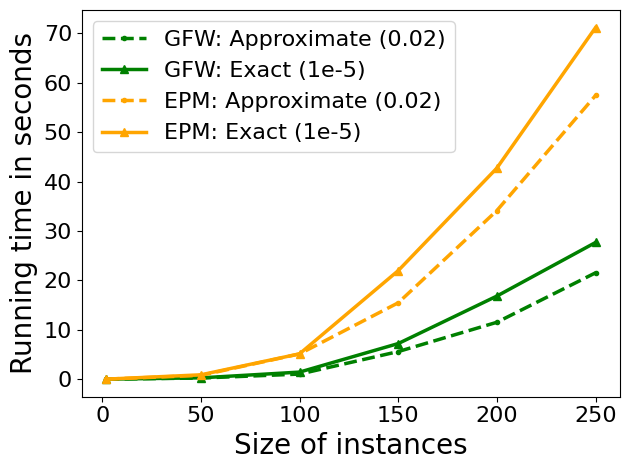

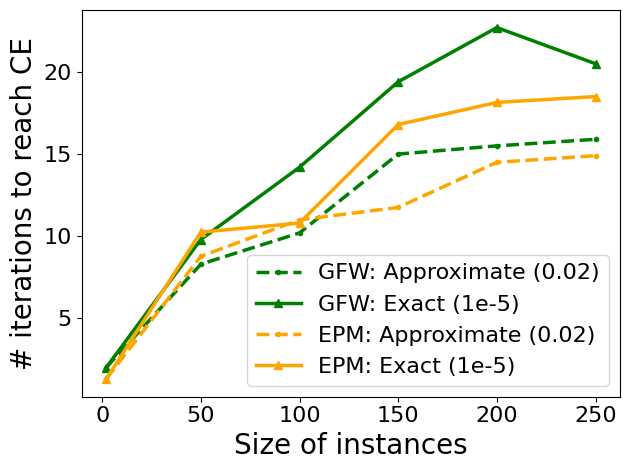

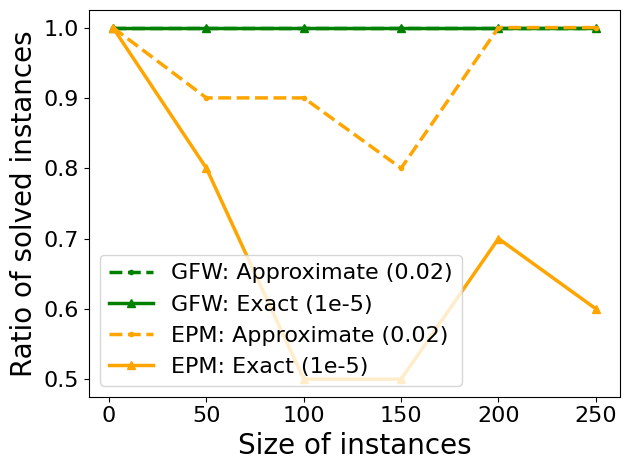

In [110]:
size_list = [2, 50, 100, 150, 200, 250]

for rgm in ['randint', ]:
    print(f"================== {rgm} ==================")
    data = run_and_save(size_list=size_list, random_generating_method=rgm, num_seeds=10, download_csv=True)
    plot_and_save(data, random_generating_method=rgm, num_seeds=10, download_fig=True)

Note:

1.   'randint (1-10)' 102*102 EPM -> simple because all equilibrium p = 1;
2.   We can change p0 to help GFW;



In [120]:
"""
Experiments on AAMAS bidding data
"""

df = pd.read_csv('/content/drive/MyDrive/chore-CEEI-experiments/bidding-data.csv')

dict_bidder_index = dict()
i = 0
for bidder in df['Bidder']:
    if bidder not in dict_bidder_index.keys():
        dict_bidder_index[bidder] = i
        i += 1

N, M = len(np.unique(df['Bidder'])), max(df['Submission'])
print(f"N = {N}, M = {M}")
B = np.ones(shape=N)

dict_pref_value = {
    'yes': 1,
    'maybe': 3,
    'no response': 5,
    'no': 7,
    'conflict': 7 * M + 1  # optimal price bound?
}

dict_pref_value_1 = {
    'yes': 0.1,
    'maybe': 1,
    'no response': 10,
    'no': 100,
    'conflict': 100 * M + 1  # optimal price bound?
}

dict_pref_value_2 = {
    'yes': 1,
    'maybe': np.sqrt(3),
    'no response': np.sqrt(5),
    'no': np.sqrt(7),
    'conflict': np.sqrt(7) * M + 1  # optimal price bound?
}

D = dict_pref_value['no response'] * np.ones(shape=(N, M))
for row in list(df.itertuples(index=False, name=None)):
    D[dict_bidder_index[row[0]]][row[1] - 1] = dict_pref_value[row[2]]

unique, counts = np.unique(D, return_counts=True)
print(unique, counts)

N = 667, M = 526
[1.000e+00 3.000e+00 5.000e+00 3.683e+03] [  6665   6253 334979   2945]


In [133]:
def run_GFW_vs_EPM_on_bidding_data(D_):

    def average(lst):  # return the average of a list
        num_nonNone = 0
        sum = 0

        for e in lst:
            if e is not None:
                num_nonNone += 1
                sum += e

        if num_nonNone > 0:
            return sum / num_nonNone
        else:
            return np.inf

    N, M = D_.shape
    num_LMO_list = [[], []]
    running_time_GFW_list = [[], []]
    num_ins_GFW_solved = [0, 0]
    data_GFW = {
        'size': f'N*M = {N}*{M}',
        'num-iter-a1': None,
        'num-iter-e': None,
        'solved-a1': None,
        'solved-e': None,
        'running-time-a1': None,
        'running-time-e': None,
    }
    num_QMO_list = [[], []]
    running_time_EPM_list = [[], []]
    num_ins_EPM_solved = [0, 0]
    data_EPM = {
        'size': f'N*M = {N}*{M}',
        'num-iter-a1': None,
        'num-iter-e': None,
        'solved-a1': None,
        'solved-e': None,
        'running-time-a1': None,
        'running-time-e': None,
    }

    B = np.ones(shape=N)

    '''
    Run the Greedy Frank Wolfe algorithm
    '''

    res_GFW = GFW(N, M, D_, B)
    # res_GFW = GFW(N, M, D_, B, return_eq=True)
    res_EPM = EPM(N, M, D_, B, QMO_solver='GUROBI', ignore_print=True)
    # res_EPM = EPM(N, M, D_, B, QMO_solver='GUROBI', ignore_print=True, return_eq=True)

    for i in range(2):
        num_ins_GFW_solved[i] += res_GFW[2 + i]
        num_ins_EPM_solved[i] += res_EPM[2 + i]
        if res_GFW[2 + i] and res_EPM[2 + i]:
            num_LMO_list[i].append(res_GFW[i])
            num_QMO_list[i].append(res_EPM[i])
            running_time_GFW_list[i].append(res_GFW[4 + i])
            running_time_EPM_list[i].append(res_EPM[4 + i])

    data_GFW['num-iter-a1'] = average(num_LMO_list[0])
    data_GFW['num-iter-e'] = average(num_LMO_list[1])
    data_GFW['solved-a1'] = num_ins_GFW_solved[0]
    data_GFW['solved-e'] = num_ins_GFW_solved[1]
    data_GFW['running-time-a1'] = average(running_time_GFW_list[0])
    data_GFW['running-time-e'] = average(running_time_GFW_list[1])

    data_EPM['num-iter-a1'] = average(num_QMO_list[0])
    data_EPM['num-iter-e'] = average(num_QMO_list[1])
    data_EPM['solved-a1'] = num_ins_EPM_solved[0]
    data_EPM['solved-e'] = num_ins_EPM_solved[1]
    data_EPM['running-time-a1'] = average(running_time_EPM_list[0])
    data_EPM['running-time-e'] = average(running_time_EPM_list[1])

    return data_GFW, data_EPM

In [134]:
def cluster_and_sort(D, n_clusters=60, random_state=2024):  # sort groups by frequency

    X = D.T
    clusters = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto").fit(X)
    unique, counts = np.unique(clusters.labels_, return_counts=True)
    # print(unique, counts)
    count_sorted_groups = np.argsort(counts)

    return clusters, count_sorted_groups

In [135]:
def get_sampled_bidding_data(D, clusters, selected_label, show_selected=True):

    N, M = D.shape
    selected_reviewers = []
    selected_papers = []
    for j in range(M):
        if clusters.labels_[j] in selected_label:
            selected_papers.append(j)
            for i in range(N):
                if D[i][j] != 5:
                    selected_reviewers.append(i)
    selected_reviewers = np.unique(selected_reviewers)
    selected_papers = np.unique(selected_papers)
    selected_reviewers = np.random.choice(selected_reviewers, size=len(selected_papers), replace=False)
    selected_papers = np.sort(selected_papers)
    selected_reviewers = np.sort(selected_reviewers)

    if show_selected:
        print()
        print("selected papers", selected_papers)
        print("selected reviewers", selected_reviewers)

    D_sampled = D[np.ix_(selected_reviewers, selected_papers)]

    return D_sampled

In [136]:
def run_and_save_sampled_bidding_data(D, cut_list=[9, 20, 30, 40, 50, 55, 60], with_noise=True, download_csv=False, show_selected=True):

    clusters, count_sorted_groups = cluster_and_sort(D)

    dict_ = {
        'x': list(),
        'i_y1': list(),
        'i_y2': list(),
        'i_z1': list(),
        'i_z2': list(),
        's_y1': list(),
        's_y2': list(),
        's_z1': list(),
        's_z2': list(),
        'r_y1': list(),
        'r_y2': list(),
        'r_z1': list(),
        'r_z2': list()
    }

    if with_noise:
        print("================== Sampled Bidding Data with Uniform Noise ==================")
    else:
        print("================== Sampled Bidding Data without Noise ==================")

    for i in cut_list:
        selected_label = count_sorted_groups[:i + 1]
        D_sampled = get_sampled_bidding_data(D, clusters, selected_label, show_selected)
        size = D_sampled.shape[0]
        dict_['x'].append(size)
        print(f"================== Cut: {i}; Size: {size} ==================")
        N, M = D_sampled.shape
        if with_noise:
            noise = np.random.uniform(size=(N, M))
            res_GFW_bidding_data, res_EPM_bidding_data = run_GFW_vs_EPM_on_bidding_data(D_sampled + noise)
        else:
            res_GFW_bidding_data, res_EPM_bidding_data = run_GFW_vs_EPM_on_bidding_data(D_sampled)

        dict_['i_y1'].append(res_GFW_bidding_data['num-iter-a1'])
        dict_['s_y1'].append(res_GFW_bidding_data['solved-a1'])
        dict_['r_y1'].append(res_GFW_bidding_data['running-time-a1'])
        dict_['i_y2'].append(res_GFW_bidding_data['num-iter-e'])
        dict_['s_y2'].append(res_GFW_bidding_data['solved-e'])
        dict_['r_y2'].append(res_GFW_bidding_data['running-time-e'])

        dict_['i_z1'].append(res_EPM_bidding_data['num-iter-a1'])
        dict_['s_z1'].append(res_EPM_bidding_data['solved-a1'])
        dict_['r_z1'].append(res_EPM_bidding_data['running-time-a1'])
        dict_['i_z2'].append(res_EPM_bidding_data['num-iter-e'])
        dict_['s_z2'].append(res_EPM_bidding_data['solved-e'])
        dict_['r_z2'].append(res_EPM_bidding_data['running-time-e'])

    df = pd.DataFrame.from_dict(dict_)
    display(df)


    if with_noise:
        file_name = "bidding_data_with_noise.csv"
    else:
        file_name = "bidding_data_without_noise.csv"
    df.to_csv(file_name)
    if download_csv:
        files.download(file_name)

    return dict_, file_name

In [137]:
"""
plot and save
"""

def plot_and_save_bidding_data(data, file_name, download_fig=False):

    plt.figure()
    plt.plot(data['x'], data['r_y1'], label=f'GFW: Approximate ({APPROXIMATE_THR})', marker='.', color='g', linestyle='dashed', linewidth=2.5)
    plt.plot(data['x'], data['r_y2'], label=f'GFW: Exact (1e-5)', marker='^', color='g', linewidth=2.5)
    plt.plot(data['x'], data['r_z1'], label=f'EPM: Approximate ({APPROXIMATE_THR})', marker='.', color='orange', linestyle='dashed', linewidth=2.5)
    plt.plot(data['x'], data['r_z2'], label=f'EPM: Exact (1e-5)', marker='^', color='orange', linewidth=2.5)

    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel("Size of instances", fontsize=20)
    plt.ylabel("Running time in seconds", fontsize=20)
    plt.legend(fontsize=16)
    plt.tight_layout()

    plt.savefig(f"rt_{file_name}.png")
    if download_fig:
        files.download(f"rt_{file_name}.png")


    plt.figure()
    plt.plot(data['x'], data['i_y1'], label=f'GFW: Approximate ({APPROXIMATE_THR})', marker='.', color='g', linestyle='dashed', linewidth=2.5)
    plt.plot(data['x'], data['i_y2'], label=f'GFW: Exact (1e-5)', marker='^', color='g', linewidth=2.5)
    plt.plot(data['x'], data['i_z1'], label=f'EPM: Approximate ({APPROXIMATE_THR})', marker='.', color='orange', linestyle='dashed', linewidth=2.5)
    plt.plot(data['x'], data['i_z2'], label=f'EPM: Exact (1e-5)', marker='^', color='orange', linewidth=2.5)

    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel("Size of instances", fontsize=20)
    plt.ylabel("# iterations to reach CE", fontsize=20)
    plt.legend(fontsize=16)
    plt.tight_layout()

    plt.savefig(f"ni_{file_name}.png")
    if download_fig:
        files.download(f"ni_{file_name}.png")

================== Sampled Bidding Data without Noise ==================

selected papers [ 27  85 148 219 274 321 362 433 435 442]
selected reviewers [ 58  76  99 158 193 301 394 535 545 644]
================== Cut: 9; Size: 10 ==================

selected papers [  1  27  40  52  59  85 116 148 151 154 171 211 219 248 254 274 321 331
 350 362 410 419 433 435 441 442 468 480 506 508 521]
selected reviewers [  7  17  18  48  65  80  83 120 134 140 161 254 275 303 306 387 388 392
 399 423 426 458 484 492 498 544 552 567 595 606 634]
================== Cut: 20; Size: 31 ==================

selected papers [  1  11  22  27  40  52  59  69  85 116 146 148 151 154 171 181 185 191
 193 211 212 219 240 246 248 251 252 254 274 291 321 331 350 360 362 378
 384 410 419 430 433 435 436 438 441 442 445 452 468 470 473 480 487 492
 499 506 508 517 521]
selected reviewers [  1   9  26  62  70  71  72  88  97  99 100 103 127 129 131 135 145 151
 153 175 206 215 225 226 248 251 254 271 281 290 324 329

,x,i_y1,i_y2,i_z1,i_z2,s_y1,s_y2,s_z1,s_z2,r_y1,r_y2,r_z1,r_z2
0,10,2.0,2.0,1.0,1.0,1,1,1,1,0.009763,0.009763,0.030535,0.030535
1,31,3.0,3.0,3.0,3.0,1,1,1,1,0.047176,0.047176,0.303636,0.303636
2,59,3.0,3.0,3.0,3.0,1,1,1,1,0.172694,0.172694,1.601131,1.601131
3,90,3.0,3.0,4.0,4.0,1,1,1,1,0.530032,0.530032,3.494428,3.494428
4,135,3.0,3.0,3.0,3.0,1,1,1,1,0.972456,0.972456,5.004398,5.004398
5,169,3.0,3.0,3.0,3.0,1,1,1,1,2.056866,2.056866,10.789460,10.789460
6,526,5.0,5.0,4.0,4.0,1,1,1,1,63.258876,63.258876,139.822028,139.822028


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

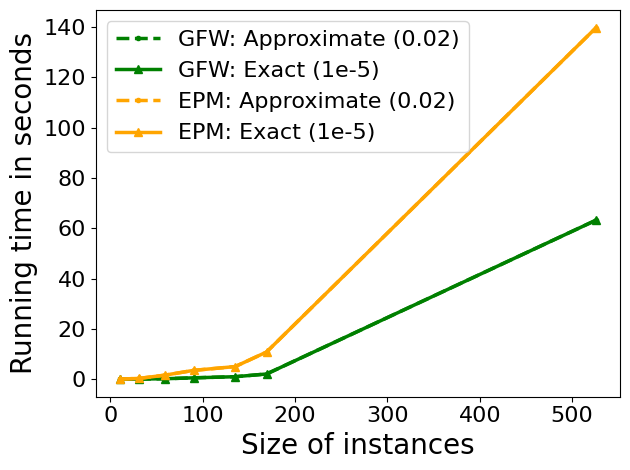

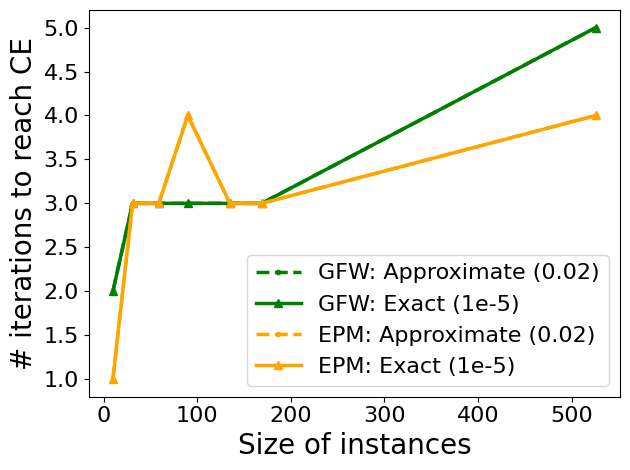

In [131]:
data, file_name = run_and_save_sampled_bidding_data(D, with_noise=False, download_csv=True, show_selected=False)
plot_and_save_bidding_data(data, file_name, download_fig=True)

================== Sampled Bidding Data with Uniform Noise ==================
================== Cut: 9; Size: 10 ==================
================== Cut: 20; Size: 31 ==================
================== Cut: 30; Size: 59 ==================
================== Cut: 40; Size: 90 ==================
================== Cut: 50; Size: 135 ==================
================== Cut: 55; Size: 169 ==================
================== Cut: 60; Size: 526 ==================


,x,i_y1,i_y2,i_z1,i_z2,s_y1,s_y2,s_z1,s_z2,r_y1,r_y2,r_z1,r_z2
0,10,2.0,3.0,2.0,2.0,1,1,1,1,0.009996,0.013427,0.017445,0.017445
1,31,3.0,3.0,3.0,3.0,1,1,1,1,0.034418,0.034418,0.041172,0.041172
2,59,3.0,4.0,4.0,4.0,1,1,1,1,0.183225,0.242885,0.450895,0.450895
3,90,4.0,6.0,5.0,8.0,1,1,1,1,0.399740,0.573660,1.740152,2.718214
4,135,inf,inf,inf,inf,1,1,0,0,inf,inf,inf,inf
5,169,7.0,inf,5.0,inf,1,1,1,0,13.661611,inf,9.265981,inf
6,526,11.0,inf,11.0,inf,1,1,1,0,257.490162,inf,225.036362,inf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

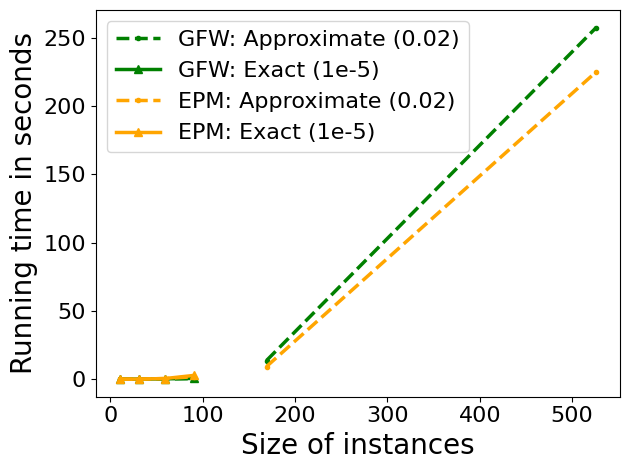

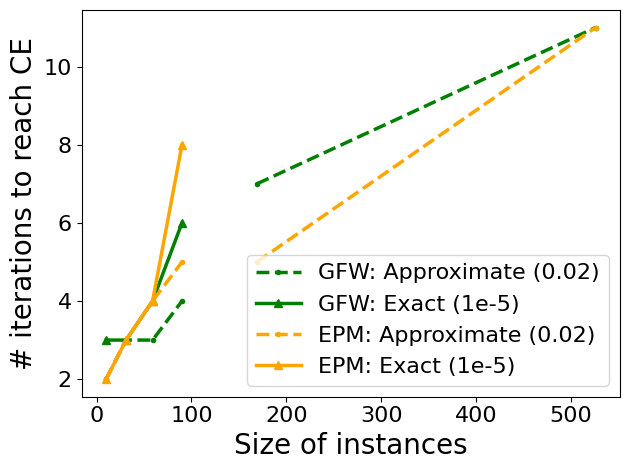

In [138]:
data, file_name = run_and_save_sampled_bidding_data(D, with_noise=True, download_csv=True, show_selected=False)
plot_and_save_bidding_data(data, file_name, download_fig=True)